# FMATCH 7/10 — Product assembly (`product.py`)

**PR topic**: the orchestrator that combines every previous layer of this stack into
a conformant FMATCH dataset:

1. `build_radiometer_footprints` — L1B pass-through arrays → per-footprint
   `RadiometerFootprint`s with **ray-traced bounding boxes** (PR 1 geometry) when the
   L1B scan reference is present, falling back to boresight-centred boxes when not.
2. `aggregate_external_variables` — for each footprint, fetch merged tiles through
   the caching `TileManager` (PR 4), weight cells with the PSF weigher (PR 5), apply
   each variable's aggregation strategy, and emit one value per footprint per
   product variable — plus the per-footprint **coverage** (minimum across sources).
3. `assemble_fmatch_dataset` — assemble the pass-through, derived
   (`sunglint_angle`), aggregated, and QA columns into an `xarray.Dataset` validated
   against the mode's product definition (PR 6).

In [1]:
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
from libera_utils.footprint_matching import product
from libera_utils.footprint_matching.readers.era5 import ERA5Reader
from libera_utils.footprint_matching.tiling import TileManager
from libera_utils.footprint_matching.types import OperationalMode
from tests.test_data.footprint_matching.fixtures import make_era5_netcdf_fixture

## Setup: a synthetic L1B segment

40 radiometer footprints along a track, with the full scan reference (subsatellite
point + cone-angle rate) so the assembly uses the ray-traced boxes and the
CERES-faithful angular PSF weigher.

In [3]:
n = 40
rng = np.random.default_rng(11)
scan = np.linspace(-60, 60, n)  # signed scan angle across the track

l1b_inputs = {
    "RADIOMETER_TIME": np.datetime64("2026-01-01T06:00:00") + (np.arange(n) * 350).astype("timedelta64[ms]"),
    "latitude": np.linspace(30.0, 34.0, n),
    "longitude": -105.0 + np.tan(np.radians(scan)) * 835.0 / 111.0,
    "solar_zenith_angle": np.full(n, 40.0) + rng.normal(0, 1, n),
    "viewing_zenith_angle": np.abs(scan),
    "relative_azimuth_angle": rng.uniform(0, 360, n),
    "subsatellite_latitude": np.linspace(30.0, 34.0, n),
    "subsatellite_longitude": np.full(n, -105.0),
    "cone_angle_rate": np.full(n, 4.0),
}

## 1. Footprint geometry: ray-traced boxes vs the boresight fallback

With the scan reference, boxes are the true PSF ray-trace (bigger and asymmetric at
the swath edge); a minimal dict without it degrades gracefully to boresight boxes.

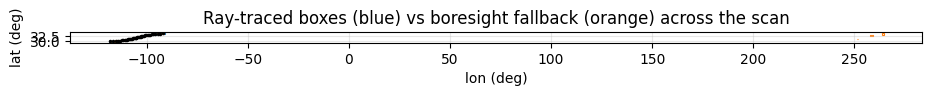

In [4]:
footprints = product.build_radiometer_footprints(l1b_inputs)
minimal = {k: l1b_inputs[k] for k in ("latitude", "longitude", "viewing_zenith_angle")}
fallback = product.build_radiometer_footprints(minimal)

fig, ax = plt.subplots(figsize=(11, 4))
for fp, fb in zip(footprints, fallback, strict=True):
    for box, color in ((fp.bbox, "tab:blue"), (fb.bbox, "tab:orange")):
        ax.add_patch(
            plt.Rectangle(
                (box.lon_min, box.lat_min),
                box.lon_max - box.lon_min,
                box.lat_max - box.lat_min,
                fill=False,
                ec=color,
                lw=0.8,
            )
        )
ax.plot(l1b_inputs["longitude"], l1b_inputs["latitude"], "k.", ms=3)
ax.set_xlabel("lon (deg)")
ax.set_ylabel("lat (deg)")
ax.set_title("Ray-traced boxes (blue) vs boresight fallback (orange) across the scan")
ax.set_aspect("equal")
ax.grid(alpha=0.3)
plt.show()

## 2. Aggregating external variables per footprint

With a tile manager holding a synthetic global ERA5 file, every footprint gets one
value per product variable, plus its coverage. (In production the manager holds all
of the mode's sources; the engine iterates whatever the manager serves.)

In [5]:
workdir = Path(tempfile.mkdtemp(prefix="fmatch_nb07_"))
era5_path = make_era5_netcdf_fixture(
    workdir, lat_min=20.0, lat_max=45.0, lon_min=-125.0, lon_max=-85.0, n_lat=101, n_lon=161
)
manager = TileManager({"era5": ERA5Reader(era5_path)}, OperationalMode.CAM)
try:
    values, coverage = product.aggregate_external_variables(
        OperationalMode.CAM, footprints, tile_manager=manager, return_coverage=True
    )
finally:
    manager.shutdown()

print(f"{len(values)} aggregated variables per footprint:")
for name in list(values):
    print(f"  {name:45s} dtype={values[name].dtype}")

4 aggregated variables per footprint:
  era5_wind_u10                                 dtype=float32
  era5_wind_u10_standard_deviation              dtype=float32
  era5_wind_v10                                 dtype=float32
  era5_wind_v10_standard_deviation              dtype=float32


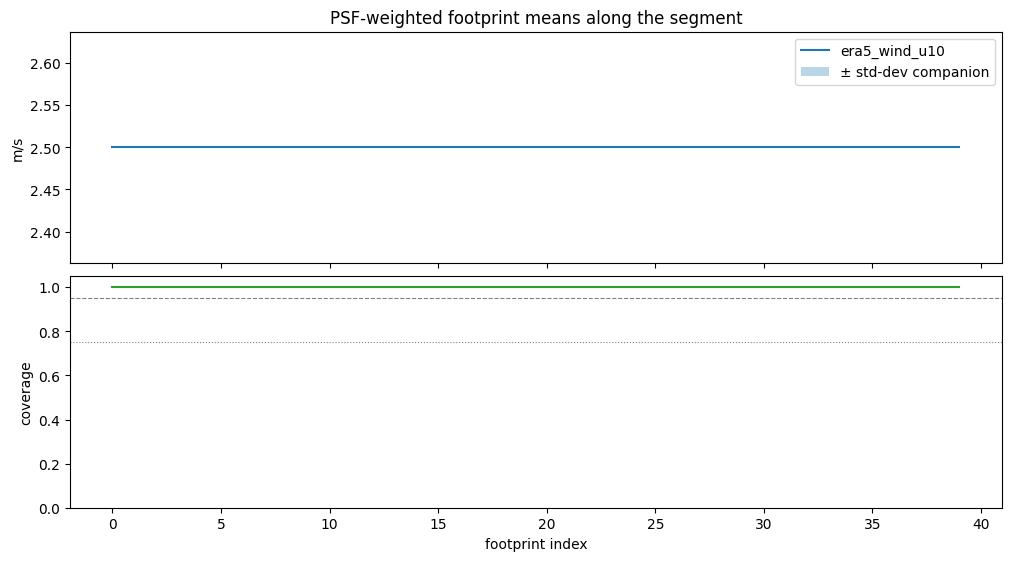

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True, constrained_layout=True)
ax1.plot(values["era5_wind_u10"], label="era5_wind_u10")
ax1.fill_between(
    np.arange(n),
    values["era5_wind_u10"] - values["era5_wind_u10_standard_deviation"],
    values["era5_wind_u10"] + values["era5_wind_u10_standard_deviation"],
    alpha=0.3,
    label="± std-dev companion",
)
ax1.set_ylabel("m/s")
ax1.legend()
ax1.set_title("PSF-weighted footprint means along the segment")
ax2.plot(coverage, color="tab:green")
ax2.axhline(0.95, color="grey", ls="--", lw=0.8)
ax2.axhline(0.75, color="grey", ls=":", lw=0.8)
ax2.set_ylabel("coverage")
ax2.set_xlabel("footprint index")
ax2.set_ylim(0, 1.05)
plt.show()

Footprints near the swath edge partially leave the synthetic file's domain, so their
coverage drops toward the CERES 75%/95% thresholds (dashed lines) and the QA merge
downstream flags or rejects them.

## 3. The full assembly: a conformant dataset

`assemble_fmatch_dataset` produces the final `xarray.Dataset` — pass-through
geolocation, derived `sunglint_angle`, aggregated ancillary variables, coverage QA,
and (for CAM) the internally supplied `cloud_fraction_camera` — validated against
the FMATCH-CAM product definition from the previous PR.

In [7]:
manager = TileManager({"era5": ERA5Reader(era5_path)}, OperationalMode.CAM)
try:
    ds = product.assemble_fmatch_dataset(
        OperationalMode.CAM,
        l1b_inputs,
        cloud_fraction_camera=rng.uniform(0, 100, n).astype(np.float32),
        tile_manager=manager,
        algorithm_version="0.0.0-demo",
        input_files="synthetic",
    )
finally:
    manager.shutdown()
ds

<xarray.Dataset> Size: 9kB
Dimensions:                                                 (RADIOMETER_TIME: 40)
Coordinates:
  * RADIOMETER_TIME                                         (RADIOMETER_TIME) datetime64[ns] 320B ...
Data variables: (12/54)
    latitude                                                (RADIOMETER_TIME) float32 160B ...
    longitude                                               (RADIOMETER_TIME) float32 160B ...
    relative_azimuth_angle                                  (RADIOMETER_TIME) float32 160B ...
    solar_zenith_angle                                      (RADIOMETER_TIME) float32 160B ...
    viewing_zenith_angle                                    (RADIOMETER_TIME) float32 160B ...
    cloud_fraction_camera                                   (RADIOMETER_TIME) float32 160B ...
    ...                                                      ...
    viirs_cloud_cloud_top_pressure                          (RADIOMETER_TIME) float32 160B ...
    viirs_cloud_cloud_top_pressure_standard_deviation       (RADIOMETER_TIME) float32 160B ...
    psf_bbox_lat_min                                        (RADIOMETER_TIME) float32 160B ...
    psf_bbox_lat_max                                        (RADIOMETER_TIME) float32 160B ...
    psf_bbox_lon_min                                        (RADIOMETER_TIME) float32 160B ...
    psf_bbox_lon_max                                        (RADIOMETER_TIME) float32 160B ...
Attributes:
    ProductID:          FMATCH-CAM
    algorithm_version:  0.0.0-demo
    InputGranules:      synthetic
    Format:             NetCDF-4
    Conventions:        CF-1.8
    ProjectLongName:    Libera
    ProjectShortName:   Libera
    PlatformLongName:   TBD
    PlatformShortName:  NOAA-22

In [8]:
print(f"{len(ds.data_vars)} variables on dims {dict(ds.sizes)}")
print(f"sunglint_angle range: [{float(ds.sunglint_angle.min()):.1f}, {float(ds.sunglint_angle.max()):.1f}] deg")
print(f"cloud_fraction_camera units: {ds.cloud_fraction_camera.attrs.get('units')}")

54 variables on dims {'RADIOMETER_TIME': 40}
sunglint_angle range: [10.4, 99.3] deg
cloud_fraction_camera units: percent


Variables whose sources were not supplied (igbp, nise, viirs) fall back to
*conformant placeholders* — the dataset always validates against the YAML, and
coverage/QA make the missing inputs visible instead of silent.

## Where this goes next in the stack

- **PR 8** adds camera segmentation, whose pseudo-footprints feed the
  camera-timescale assembly path (`CAM_CAMTIME` / `IMAGER_CAMTIME`) of this module.
- **PR 9** adds the runners: manifest in → `load_l1b_radiometer_inputs` → this
  assembly → NetCDF product out, per operational mode.